# Optimizing Coronagraph Masks
In this how-to, we will show you how to use `dygdug` for basic coronagraph optimization. This tutorial will follow the Your First Diffraction Model tutorial, so consider checking that out to understand the basics of how we define objects and coronagraphs in `dygdug`.

We will begin with the Keck-like lyot coronagraph from our tutorial. First, let's start by defining a `VariablePupil` object. `VariablePupil` is a drop-in replacement for the `Pupil` object, with the exception of being optimizeable. In this how-to, we will be using this object to improve the contrast of a coronagraph model from our previous tutorial.

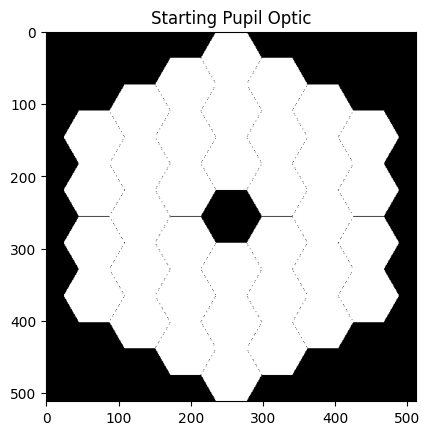

In [1]:
import matplotlib.pyplot as plt
from prysm.propagation import prepare_executor 
from prysm.segmented import VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT
from prysm.mathops import set_backend_to_cupy, np

from dygdug.masks import Pupil, FPM
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph



# Define instrument parameters
circumscribed_diameter = 10.95e3
Npup = 512
Nfoc = 128
wvl = 1 
fno = 13.66
efl = fno * circumscribed_diameter 
lamD = wvl / circumscribed_diameter * efl
px_per_lamD = 4 # the "oversampling"
seg_diam = VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT * 1800


# Define VARIABLE entrance pupil
pupil = VariablePupil.hexagonal_segmented(
    Dpup=circumscribed_diameter, 
    Npup=Npup,
    rings=3,                 
    segment_diameter=seg_diam, 
    segment_separation=5, 
    exclude=(0,),
    mode="phase" # special argument for VariablePupil
)

plt.figure()
plt.title("Starting Pupil Optic")
plt.imshow(pupil.data.real, cmap="gray")
plt.show()


Next, we just define the remaining optics and `Coronagraph` object that puts it all together

In [2]:
# ensure we are using the GPU backend
set_backend_to_cupy()

# update the VariablePupil data to be a cupy array
pupil.data = np.asarray(pupil.data)

# Define a prysm executor the controls the propagation
executor = prepare_executor(
    pupil_dx=circumscribed_diameter / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

# Define focal plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Define the lyot stop
lyot = Pupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.2 * circumscribed_diameter / 2,
    outer_radius=0.8 * circumscribed_diameter / 2
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

/home/jarenashcraft/anaconda3/envs/prysm_test/lib/python3.10/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


# Defining a Coronagraph Optimization
This is the part of `dygdug` that motivates the object-oriented structure. Here we choose to compose a coronagraph design problem with a cost quantity from `dygdug.cost_functions`, and an objective from `dygdug.coropt`.
- The `FieldMeanSquaredError` function computes the mean squared error of the real and imaginary parts of the electric field to the target specified by the user
- The `CoronagraphOptimizer` tries to minimize the FieldMeanSquaredError quantity, and returns both the function and gradient of the chosen cost function

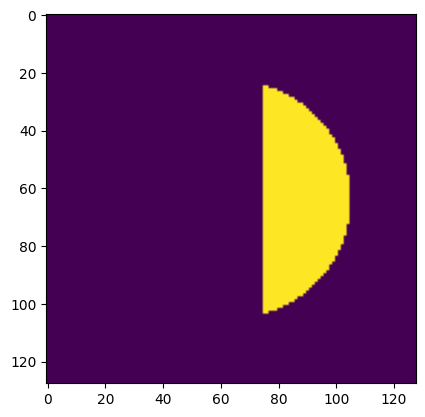

In [3]:
from dygdug.coropt import CoronagraphOptimizer
from dygdug.cost_functions import FieldMeanSquaredError
from dygdug.masks import annular_mask, ImgSamplingSpec, knife_edge_mask

# Define Image Plane Sampling Specification and Dark Hole
iss = ImgSamplingSpec(Nfoc, px_per_lamD, lamD=lamD)
dark_hole = annular_mask(iss, iwa=3, owa=12, theta_min=-90, theta_max=90)
dark_hole *= knife_edge_mask(iss, iwa=3)

plt.imshow(dark_hole.get())

# Define cost function
target_contrast = 1e-10
target_field = np.sqrt(target_contrast)
cost_function = FieldMeanSquaredError(target=target_field)

# Define the starting parameter vector
x0 = np.zeros_like(pupil.data[pupil.mask], dtype="float64")

# Define the CoronagraphOptimizer
coroopt = CoronagraphOptimizer(
    dark_hole=dark_hole,
    coro=coro,
    wvl=[wvl], # just perform monochromatic for now
    cost=cost_function
)


Next, we use `prysm`'s available optimization routines to conduct the optimization

100%|██████████| 1000/1000 [00:13<00:00, 76.21it/s]


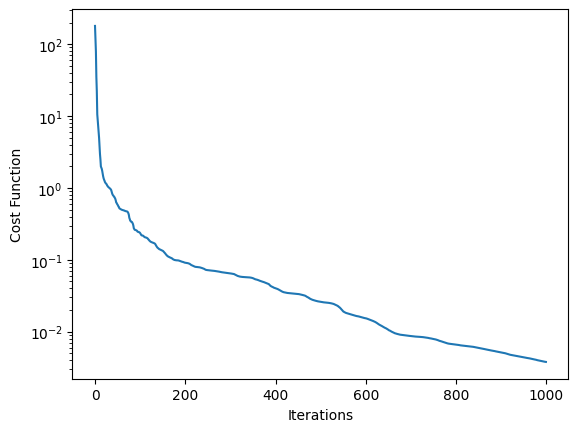

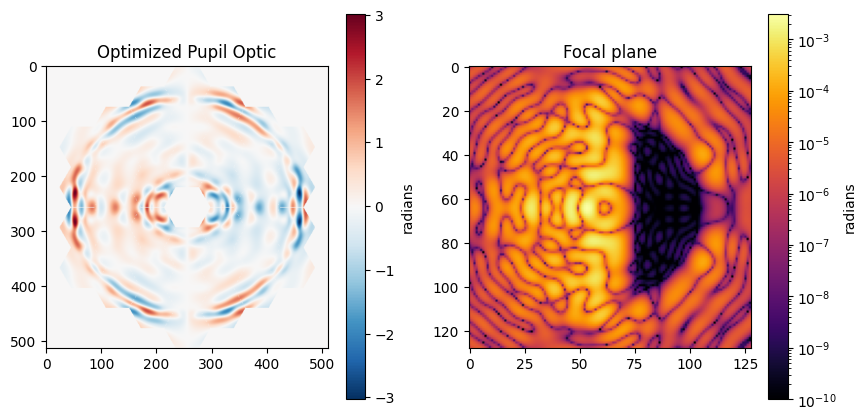

In [29]:
from tqdm import tqdm
from prysm.x.optym import PrysmLBFGSB 


opt = PrysmLBFGSB(fg=coroopt.fg, x0=x0, memory=100)
cost = []
N_ITER = 1000
for i in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)

xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure()
plt.plot(cost)
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

